In [ ]:
55. Which states have the most customers?

56. Which states generate the most revenue?

57. Which cities have the most customers?

58. What is the average order value by state?

59. Which states have higher/lower review scores?

Visualization:

Top 10 states by customers
Top 10 states by revenue

In [81]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
folder_path = "C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data"
data = {}
for file in os.listdir(folder_path):
    # print(file.split(".")[0])
    data[file.split(".")[0].replace("olist_","").replace("_dataset","").replace("order_","")] = folder_path + "/" + file
data
    

{'customers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_customers_dataset.csv',
 'geolocation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_geolocation_dataset.csv',
 'orders': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_orders_dataset.csv',
 'items': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_items_dataset.csv',
 'payments': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_payments_dataset.csv',
 'reviews': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_reviews_dataset.csv',
 'products': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_products_dataset.csv',
 'sellers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_sellers_dataset.csv',
 'product_category_name_translation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/product_category_name_transla

In [ ]:
55. Which states have the most customers?
"Business Question -> What data do I need? -> Which tables? -> Do I need merge? -> Do I need cleaning?"
             "Which Pandas function? -> Calculate -> Visualize -> Interpret -> Business insight"
I grouped customers by state, counted unique customer IDs, sorted the states in descending order, 
and selected the top 10 states. I used a bar chart to visualize the comparison.

In [82]:
df_customers = pd.read_csv(data["customers"])
df_orders = pd.read_csv(data["orders"])
df_items = pd.read_csv(data["items"])


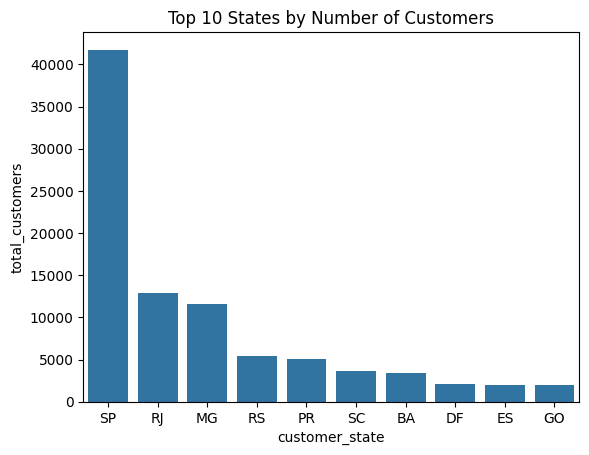

In [83]:
df_customers["customer_state"].value_counts()
top_10_states_by_customers = df_customers.groupby("customer_state")["customer_id"].nunique().reset_index(name="total_customers").sort_values("total_customers",ascending=False).head(10)
sns.barplot(data = top_10_states_by_customers,x = "customer_state",y = "total_customers")
plt.title("Top 10 States by Number of Customers")
plt.show()

In [ ]:
56. Which states generate the most revenue?
customers(customer_id),orders(customer_id)(order_id),items(order_id) 
I joined customers with orders using customer_id and then joined the result with items using order_id. I grouped the data by customer state, 
summed the item price to calculate revenue, sorted the states in descending order, and selected the top 10 states.

In [94]:
max_revenue_states

,customer_state,revenue
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


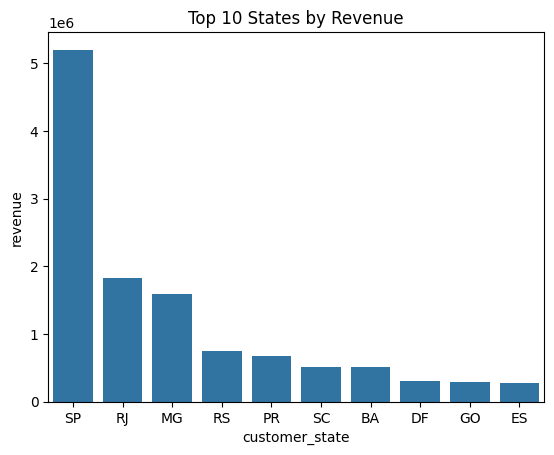

In [95]:
customers_orders = pd.merge(df_customers,df_orders,on="customer_id",how="inner")
customers_orders_items = pd.merge(customers_orders,df_items,on="order_id",how="inner")
#customers_orders_items = customers_orders_items[customers_orders_items['_merge'] == 'left_only']
max_revenue_states = customers_orders_items.groupby("customer_state")["price"].sum().sort_values(ascending=False).head(10) .reset_index(name="revenue")
sns.barplot(data = max_revenue_states,x = "customer_state",y = "revenue")
#sns.barplot(x = max_revenue_states.index,y = max_revenue_states.values)

plt.title("Top 10 States by Revenue")
plt.show()


In [ ]:
57. Which cities have the most customers?
I grouped the customers by city, counted the unique customer IDs, 
sorted the cities in descending order, and selected the top 10 cities by number of customers.
    top city having more customers: sao paulo with 15540 customers

top city having more customers: sao paulo with 15540 customers


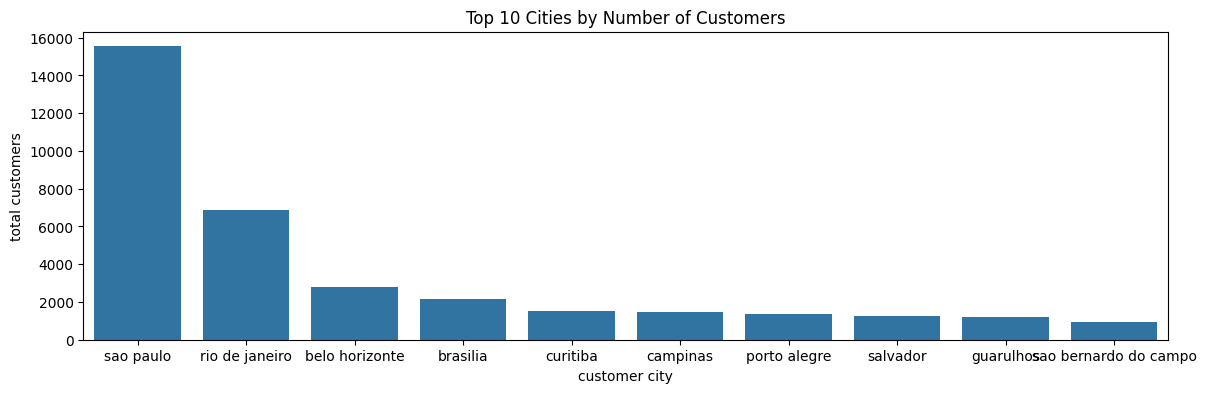

In [123]:
top_customer_cities = df_customers.groupby("customer_city")["customer_id"].nunique().sort_values(ascending=False).head(10).reset_index(name="total_customers")

top_customer_cities
print("top city having more customers:",
      top_customer_cities.loc[0,"customer_city"],
     "with",
     top_customer_cities.loc[0,"total_customers"],"customers")


plt.figure(figsize=(14,4))
sns.barplot(data = top_customer_cities,x = "customer_city",y = "total_customers")
plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("customer city")
plt.ylabel("total customers")
plt.show()

In [ ]:
58. What is the average order value by state?

First, I joined customers, orders, and order items. Since an order can contain multiple items, 
I first calculated the total price for each order by summing the item prices. 
Then I grouped those order totals by customer state and calculated the mean to get the average order value by state.

In [181]:
print("customers",df_customers.columns.tolist())
print("items",df_items.columns.tolist())
print("orders",df_orders.columns.tolist())


customers ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
items ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
orders ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [197]:
customers_orders = pd.merge(df_customers,df_orders,on="customer_id",how="inner")
order_value  = df_items.groupby("order_id")["price"].sum()
customers_orders_items = pd.merge(customers_orders,order_value,on="order_id",how="inner")

average_state_order = customers_orders_items.groupby("customer_state")["price"].mean().sort_values(ascending=False)


In [198]:
average_state_order

customer_state
PB    216.669323
AP    198.151471
AC    197.320370
AL    195.413163
RO    186.804211
PA    184.482278
TO    177.855699
PI    176.296308
MT    173.259723
RN    172.271743
CE    171.254491
SE    170.785072
RR    170.205000
MS    164.756897
MA    161.686784
PE    159.458756
BA    152.278139
AM    152.087347
GO    146.782237
SC    144.117757
RJ    142.931568
DF    142.401854
RS    138.126661
MG    137.327445
PR    136.671421
ES    135.820894
SP    125.751179
Name: price, dtype: float64

In [ ]:
59. Which states have higher/lower review scores?
Customers -> (customer_id) -> Orders -> (order_id) -> Reviews -> Group by State -> Average Review Score -> Sort

Highest review score state: AP with 4.1940298507462686 average review score
Lowest review score state: RR with 3.608695652173913 average review score

In [131]:
df_reviews = pd.read_csv(data["reviews"])
df_reviews["order_id"].nunique()
df_reviews.shape

(99224, 7)

In [201]:
customers_orders = pd.merge(df_customers,df_orders,on="customer_id",how="inner")
customers_orders_reviews = pd.merge(customers_orders,df_reviews,on="order_id",how="inner")
state_reviewscore = customers_orders_reviews.groupby("customer_state")["review_score"].mean().sort_values(ascending=False).reset_index(name="score")

#print("Highest review score state:" , state_reviewscore.iloc[0,0] ,"with",state_reviewscore.iloc[0,1],"average review score")
print("Highest review score state:" , state_reviewscore.iloc[0]["customer_state"] ,"with",state_reviewscore.iloc[0]["score"],"average review score")
print("Lowest review score state:" , state_reviewscore.iloc[-1]["customer_state"] ,"with",state_reviewscore.iloc[-1]["score"],"average review score")

Highest review score state: AP with 4.1940298507462686 average review score
Lowest review score state: RR with 3.608695652173913 average review score


In [199]:
state_reviewscore

,customer_state,score
0,AP,4.194030
1,AM,4.183673
2,PR,4.180032
3,SP,4.173951
4,MG,4.136172
5,RS,4.133321
6,MS,4.118785
7,RN,4.105809
8,MT,4.102990
9,TO,4.096774
